<h4 style="color: white";><strong>Exploración de datos BCI </strong> </h4>
<p style="font-style: italic;">Karen Agudelo Toro, Luisa Maria Hernández </p>

Consultar historia, uso y proyectos futuros relacionados con Interfaz Cerebro Computador

<p>
Esta tecnología decodifica y convierte los impulsos cerebrales en instrucciones que pueden usarse para operar computadoras, prótesis u otros dispositivos [1].Desde el punto de vista terminológico, BCI se refiere a un sistema que mide y utiliza señales adquiridas del sistema nervioso central (SNC) [2]. 
Las interfaces cerebro-computadora se clasifican según su interacción con el cerebro: las BCI invasivas implican la implantación quirúrgica de electrodos en la superficie o el interior del cerebro, proporcionando señales precisas pero conllevando mayores riesgos y dilemas éticos; por otro lado, las BCI no invasivas utilizan sensores externos, como electrodos de EEG, para detectar señales cerebrales. [1]

HISTORIA
Las interfaces cerebro- computadora (BCI) tardaron muchas décadas en evolucionar desde meras ideas teóricas hasta aplicaciones prácticas, a partir de los primeros estudios en neurofisiología y la introducción de la electroencefalografía (EEG) en el siglo XX[1]. La historia del EEG comenzó


USO
Estos sistemas pueden ayudar a algunos usuarios con discapacidad a interactuar con el entorno externo de una manera más directa, intuitiva y fácil de usar. [2]

FUTURO



<p>

## Programación

In [27]:
import mne
import matplotlib.pyplot as plt
import numpy as np
from tabulate import tabulate

### Pruebas preliminares para un solo sujeto 

Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 59 - 61 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 59.35
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 59.10 Hz)
- Upper passband edge: 60.65 Hz
- Upper transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 60.90 Hz)
- Filter length: 1057 samples (6.606 s)



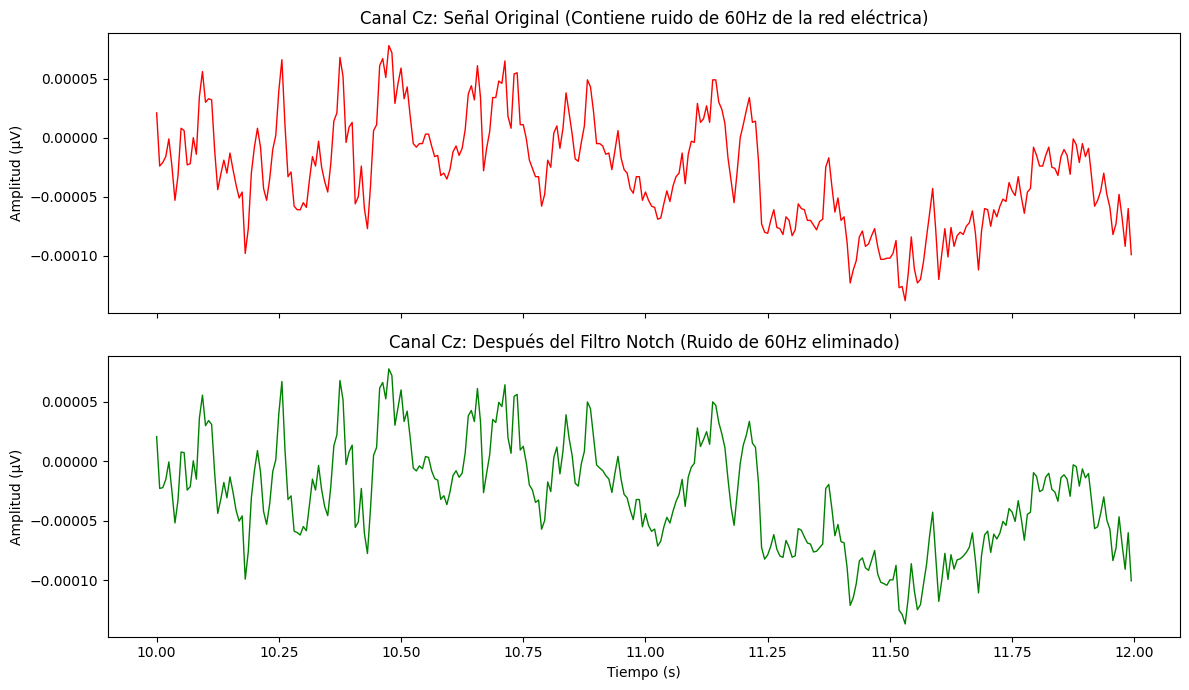

NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().
Effective window size : 12.800 (s)
Plotting power spectral density (dB=True).
Need more than one channel to make topography for eeg. Disabling interactivity.
NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().
Effective window size : 12.800 (s)
Plotting power spectral density (dB=True).
Need more than one channel to make topography for eeg. Disabling interactivity.


c:\Users\lmari\miniconda3\Lib\site-packages\mne\viz\utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)
c:\Users\lmari\miniconda3\Lib\site-packages\mne\viz\utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


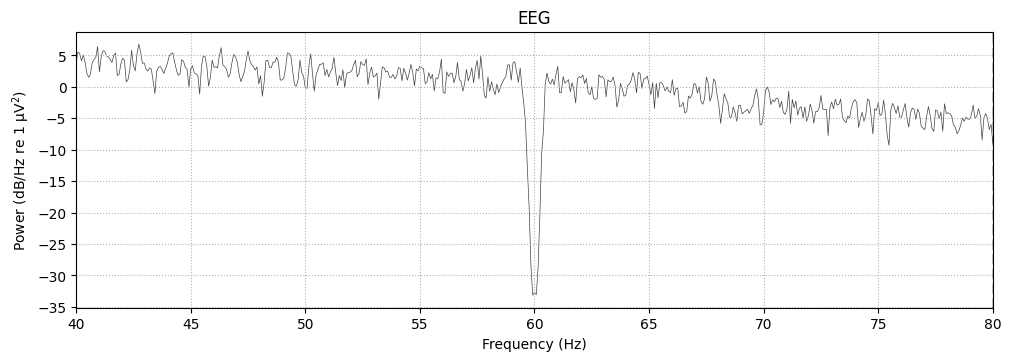

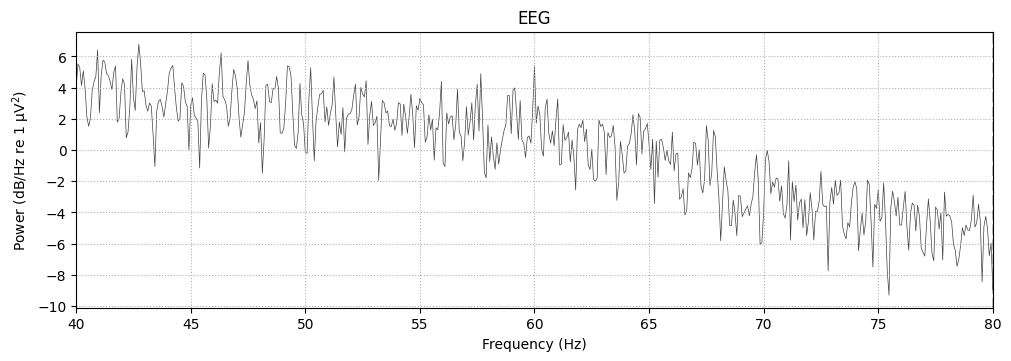

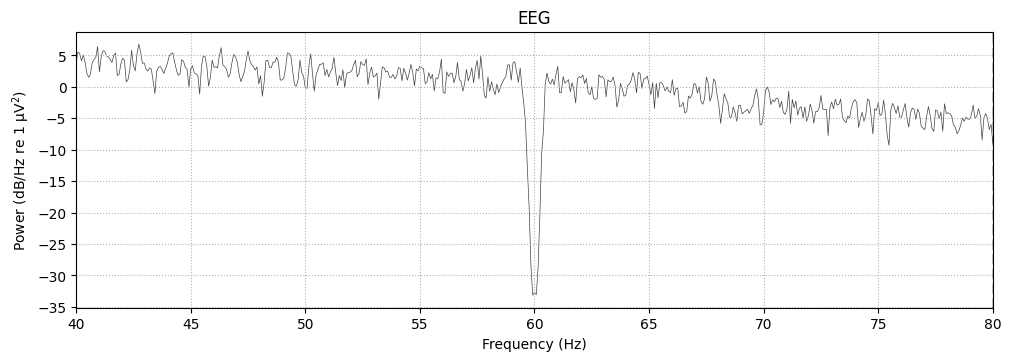

In [ ]:


# 1. Definir la ruta y cargar el archivo (usando 'r' para evitar errores de dirección)
path = r"sub-001_task-motion_run-4_eeg.set"
raw = mne.io.read_raw_eeglab(path, preload=True)

# 2. Crear una copia y aplicar  el filtro Notch (60 Hz)
raw_notch = raw.copy().notch_filter(freqs=60, method='fir')

# 3. Extraer datos para graficar y comparar
# Elegimos el canal 'Cz' y un segmento de 2 segundos para que el ruido sea visible
canal = 'Cz'
canal_idx = raw.ch_names.index(canal)
start, stop = raw.time_as_index([10, 12])  # Del segundo 10 al 12

tiempos = raw.times[start:stop]
señal_original = raw.get_data()[canal_idx, start:stop]
señal_con_notch = raw_notch.get_data()[canal_idx, start:stop]

# --- GRAFICAR ---
fig, ax = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

# Señal Original
ax[0].plot(tiempos, señal_original, color='red', lw=1)
ax[0].set_title(f"Canal {canal}: Señal Original (Contiene ruido de 60Hz de la red eléctrica)")
ax[0].set_ylabel("Amplitud (µV)")

# Señal con Notch
ax[1].plot(tiempos, señal_con_notch, color='green', lw=1)
ax[1].set_title(f"Canal {canal}: Después del Filtro Notch (Ruido de 60Hz eliminado)")
ax[1].set_xlabel("Tiempo (s)")
ax[1].set_ylabel("Amplitud (µV)")

plt.tight_layout()
plt.show()

# --- COMPROBACIÓN ESPECTRAL (PSD) ---

raw.plot_psd(fmin=40, fmax=80, picks=[canal])      
raw_notch.plot_psd(fmin=40, fmax=80, picks=[canal]) 

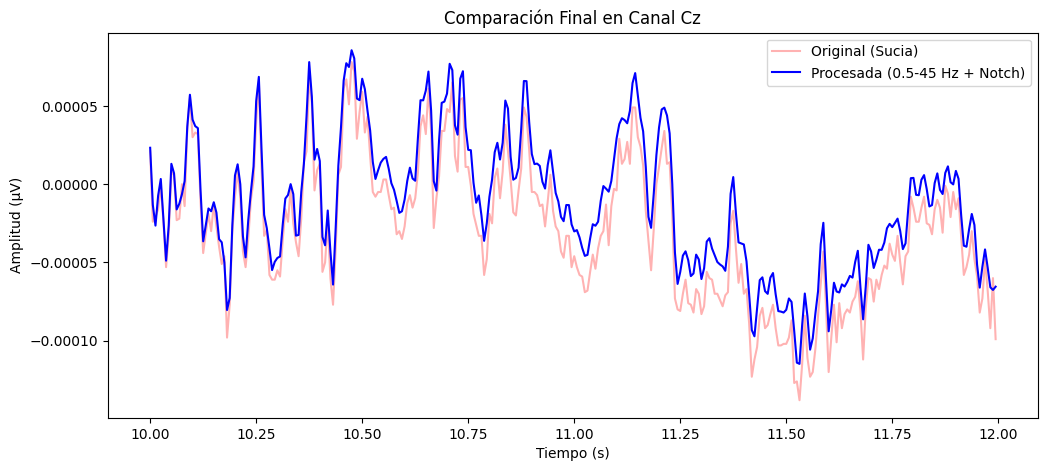

NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().
Effective window size : 12.800 (s)
Plotting power spectral density (dB=True).
Need more than one channel to make topography for eeg. Disabling interactivity.
NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().
Effective window size : 12.800 (s)
Plotting power spectral density (dB=True).
Need more than one channel to make topography for eeg. Disabling interactivity.


c:\Users\lmari\miniconda3\Lib\site-packages\mne\viz\utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)
c:\Users\lmari\miniconda3\Lib\site-packages\mne\viz\utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


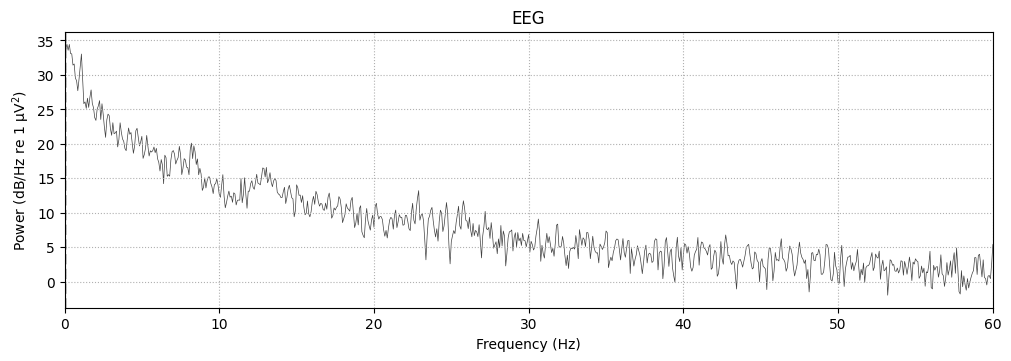

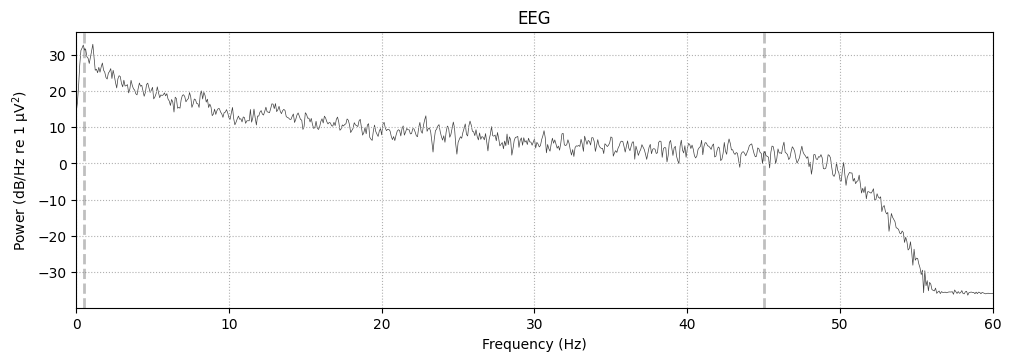

In [16]:
# BLOQUE DE FILTRADO PASA-BANDA (0.5 - 45 Hz) 
# Definimos los límites
f_min = 0.5
f_max = 45.0

# Aplicamos el filtro sobre la señal que ya no tiene los 60Hz
raw_final = raw_notch.copy().filter(l_freq=f_min, h_freq=f_max, method='fir', verbose=False)

# Extraer datos para comparar el resultado final
señal_final = raw_final.get_data()[canal_idx, start:stop]

# --- GRAFICAR EL RESULTADO GLOBAL ---
plt.figure(figsize=(12, 5))
plt.plot(tiempos, señal_original, color='red', alpha=0.3, label='Original (Sucia)')
plt.plot(tiempos, señal_final, color='blue', label='Procesada (0.5-45 Hz + Notch)')
plt.title(f"Comparación Final en Canal {canal}")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud (µV)")
plt.legend()
plt.show()


raw.plot_psd(fmin=0, fmax=60, picks=[canal])
raw_final.plot_psd(fmin=0, fmax=60, picks=[canal])
plt.show()

In [33]:
# 1. Extraer eventos de la señal ya filtrada
events, event_id = mne.events_from_annotations(raw_final)

# 2. Definir el diccionario con las 3 condiciones
eventos_interes = {
    'reposo': event_id['TASK2T0'],
    'izquierda': event_id['TASK2T1'],
    'derecha': event_id['TASK2T2']
}

# 3. Crear las épocas usando raw_final
# tmin=0 y tmax=2 extrae segmentos de 2 segundos por cada tarea
epocas = mne.Epochs(raw_final, events, event_id=eventos_interes, 
                    tmin=0, tmax=2, baseline=None, preload=True, verbose=False)

# 4. Separar las señales en variables independientes
data_reposo = epocas['reposo'].get_data()
data_izquierda = epocas['izquierda'].get_data()
data_derecha = epocas['derecha'].get_data()

# Verificación de que se dividieron correctamente
print(f"Épocas extraídas de raw_final:")
print(f"- Reposo: {len(data_reposo)}")
print(f"- Mano Izquierda: {len(data_izquierda)}")
print(f"- Mano Derecha: {len(data_derecha)}")

Used Annotations descriptions: [np.str_('TASK2T0'), np.str_('TASK2T1'), np.str_('TASK2T2')]
Épocas extraídas de raw_final:
- Reposo: 15
- Mano Izquierda: 8
- Mano Derecha: 7


NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().


C:\Users\lmari\AppData\Local\Temp\ipykernel_20752\1232400700.py:30: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


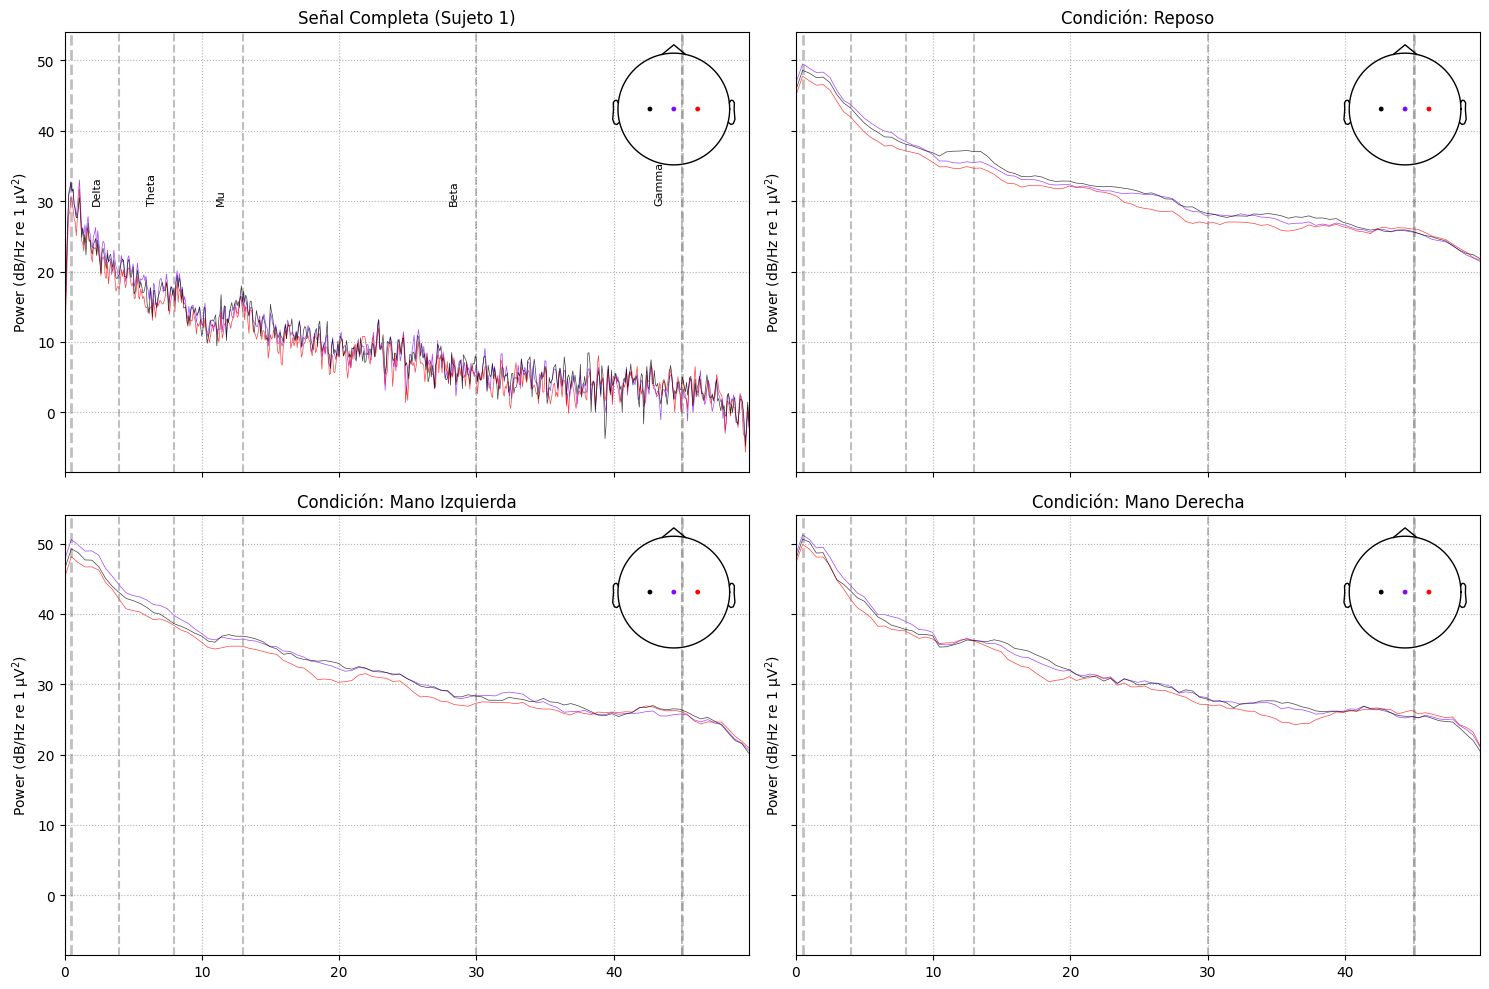

In [36]:
# --- GRÁFICAS PSD EN SUBPLOTS ---

bandas_limites = {'Delta': 4, 'Theta': 8, 'Mu': 13, 'Beta': 30, 'Gamma': 45}
canales = ['C3', 'Cz', 'C4']

fig, axes = plt.subplots(2, 2, figsize=(15, 10), sharex=True, sharey=True)
axs = axes.flatten()

# Definición de datos para cada subplot
config = [
    (raw_final, "Señal Completa (Sujeto 1)"),
    (epocas['reposo'], "Condición: Reposo"),
    (epocas['izquierda'], "Condición: Mano Izquierda"),
    (epocas['derecha'], "Condición: Mano Derecha")
]

for i, (obj_eeg, titulo) in enumerate(config):
    # Generar PSD para el subplot correspondiente
    obj_eeg.plot_psd(fmin=0, fmax=50, picks=canales, ax=axs[i], show=False, verbose=False)
    axs[i].set_title(titulo)
    
    # Añadir líneas de bandas
    for nombre, freq in bandas_limites.items():
        axs[i].axvline(x=freq, color='gray', linestyle='--', alpha=0.5)
        # Etiquetas de texto solo en el primer subplot para mantener limpieza
        if i == 0:
            axs[i].text(freq - 2, axs[i].get_ylim()[1] * 0.85, nombre, 
                        rotation=90, fontsize=8, color='black')

plt.tight_layout()
plt.show()

Punto Negro: Representa el canal C3 (Hemisferio Izquierdo - Corteza Motora)

Punto Morado: Representa el canal Cz (Línea central)

Punto Rojo: Representa el canal C4 (Hemisferio Derecho - Corteza Motora)


### 2.1 Funcion de procesamiento 

In [51]:


# Diccionario global para almacenar los datos segmentados
diccionario_senales = {}

def procesar_y_segmentar_eeg(ruta_completa, diccionario_destino):
    # 1. Extraer ID del sujeto y número de run del nombre del archivo
    nombre_archivo = os.path.basename(ruta_completa)
    partes = nombre_archivo.split('_')
    id_sujeto = partes[0]  # Ejemplo: sub-001
    run_info = partes[2]   # Ejemplo: run-4
    
    # Extraer solo el número (4, 8 o 12)
    numero_run = run_info.split('-')[1]
    
    # Definir condición como 'real' para estos números
    condicion = "real" if numero_run in ['4', '8', '12'] else "otra"

    # 2. Cargar y filtrar (Notch + Pasa-banda)
    raw = mne.io.read_raw_eeglab(ruta_completa, preload=True, verbose=False)
    raw.notch_filter(freqs=60, method='fir', verbose=False)
    raw.filter(l_freq=0.5, h_freq=45.0, method='fir', verbose=False)

    # 3. Extraer Eventos y Épocas
    events, event_id = mne.events_from_annotations(raw, verbose=False)
    
    eventos_dict = {
        'reposo': event_id['TASK2T0'],
        'izquierda': event_id['TASK2T1'],
        'derecha': event_id['TASK2T2']
    }

    epocas = mne.Epochs(raw, events, event_id=eventos_dict, 
                        tmin=0, tmax=2, baseline=None, preload=True, verbose=False)

    # 4. Crear la llave solicitada: sujeto_numero_real
    llave_final = f"{id_sujeto}_{numero_run}_{condicion}"
    
    # Guardar matrices de datos (n_epocas, n_canales, n_muestras)
    diccionario_destino[llave_final] = {
        'reposo': epocas['reposo'].get_data(),
        'izquierda': epocas['izquierda'].get_data(),
        'derecha': epocas['derecha'].get_data()
    }
    
    print(f"Datos guardados en: {llave_final}")
    return diccionario_destino



### 2.2 y 2.3 Calculo de PSD y almacenamiento en Datafranme

In [55]:
import mne
import os
import numpy as np
from tabulate import tabulate

# Diccionario global
diccionario_senales = {}

def procesar_y_segmentar_eeg(ruta_completa, diccionario_destino):
    nombre_archivo = os.path.basename(ruta_completa)
    partes = nombre_archivo.split('_')
    id_sujeto = partes[0]  
    run_info = partes[2]   
    
    numero_run = run_info.split('-')[1]
    condicion = "real" if numero_run in ['4', '8', '12'] else "otra"

    # Seleccionamos solo los canales de interés desde la carga para ahorrar memoria
    raw = mne.io.read_raw_eeglab(ruta_completa, preload=True, verbose=False)
    raw.pick_channels(['C3', 'Cz', 'C4']) # Esto asegura que el orden en el diccionario sea siempre [0,1,2]
    
    raw.notch_filter(freqs=60, method='fir', verbose=False)
    raw.filter(l_freq=0.5, h_freq=45.0, method='fir', verbose=False)

    events, event_id = mne.events_from_annotations(raw, verbose=False)
    
    eventos_dict = {
        'reposo': event_id['TASK2T0'],
        'izquierda': event_id['TASK2T1'],
        'derecha': event_id['TASK2T2']
    }

    epocas = mne.Epochs(raw, events, event_id=eventos_dict, 
                        tmin=0, tmax=2, baseline=None, preload=True, verbose=False)

    llave_final = f"{id_sujeto}_{numero_run}_{condicion}"
    
    # Guardamos los datos
    diccionario_destino[llave_final] = {
        'reposo': epocas['reposo'].get_data(),
        'izquierda': epocas['izquierda'].get_data(),
        'derecha': epocas['derecha'].get_data()
    }
    
    print(f"Procesado: {llave_final}")
    return diccionario_destino # Retornamos el diccionario actualizado

# --- RUTINA DE EJECUCIÓN ---
folder_path = 'sujetos'

for archivo in os.listdir(folder_path):
    if archivo.endswith(".set"):
        ruta_full = os.path.join(folder_path, archivo)
        try:
            # Actualizamos el diccionario global en cada iteración
            diccionario_senales = procesar_y_segmentar_eeg(ruta_full, diccionario_senales)
        except Exception as e:
            print(f"Error procesando {archivo}: {e}")

# 1. Recorrer el diccionario principal
for llave_principal, sub_diccionario in diccionario_senales.items():
    # Obtener las llaves del diccionario interno
    llaves_internas = list(sub_diccionario.keys())
    
    print(f"Archivo: {llave_principal}")
    print(f"   └── Condiciones encontradas: {llaves_internas}")
    
    # Opcional: ver el tamaño de los datos de una condición para estar seguro
    for condicion in llaves_internas:
        shape = sub_diccionario[condicion].shape
        print(f"       {condicion}: {shape} (Épocas, Canales, Muestras)")
    print("-" * 50)

NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Procesado: sub-001_12_real
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Procesado: sub-001_4_real
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Procesado: sub-001_8_real
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Procesado: sub-004_12_real
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Procesado: sub-004_4_real
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Procesado: sub-004_8_real
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Procesado: sub-012_12_real
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Procesado: sub-012_4_real
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Procesado: sub-012_8_real
NOTE: pick_channels() is a legacy function.

In [ ]:
from scipy import signal


# 1. Configuración
sfreq = 160  
canales_nombres = ['C3', 'Cz', 'C4'] 
bandas_interes = {'Mu': (8, 13), 'Beta': (14, 30)}

filas_dataframe = []

print(f"Iniciando diagnóstico... Total de llaves en el diccionario: {len(diccionario_senales)}")

# 2. Bucle de procesamiento
for llave_sujeto, sub_diccionario in diccionario_senales.items():
    partes = llave_sujeto.split('_')
    sujeto_id = partes[0]
    run_id = partes[1]
    
    # Ver cuántas condiciones tiene ESTA llave
    condiciones_reales = list(sub_diccionario.keys())
    
    for condicion in ['reposo', 'izquierda', 'derecha']:
        if condicion not in sub_diccionario:
            # ESTO TE DIRÁ SI FALTA UNA CONDICIÓN
            print(f" Alerta: {llave_sujeto} no tiene la condición '{condicion}'")
            continue
            
        matriz_datos = sub_diccionario[condicion]
        
        # Verificar que la matriz tenga datos (épocas > 0)
        if not isinstance(matriz_datos, np.ndarray) or matriz_datos.shape[0] == 0:
            print(f"Error: {llave_sujeto} - {condicion} está vacío (Shape: {matriz_datos.shape})")
            continue
            
        # Calcular Welch
        freqs, psds = signal.welch(matriz_datos, fs=sfreq, nperseg=sfreq, axis=-1)
        psd_avg = np.mean(psds, axis=0) 

        for i, ch_name in enumerate(canales_nombres):
            for b_nombre, (f_min, f_max) in bandas_interes.items():
                idx_banda = np.logical_and(freqs >= f_min, freqs <= f_max)
                potencia_media = psd_avg[i, idx_banda].mean()
                
                filas_dataframe.append({
                    'Sujeto': sujeto_id,
                    'Run': run_id,
                    'Condicion': condicion,
                    'Canal': ch_name,
                    'Banda': b_nombre,
                    'Potencia_PSD': potencia_media
                })

# 3. Crear DataFrame
df_resultados = pd.DataFrame(filas_dataframe)

# 4. REPORTE FINAL DE FILAS
print("\n" + "="*30)
print(f"ANÁLISIS DE DATOS FINALIZADO")
print(f"Filas totales generadas: {len(df_resultados)}")
print("="*30)

if not df_resultados.empty:
    # Ver cuántos sujetos hay realmente
    print(f"Sujetos únicos encontrados: {df_resultados['Sujeto'].nunique()}")
    print(f"Condiciones encontradas: {df_resultados['Condicion'].unique()}")
    
    # Imprimir TODO el dataframe si es pequeño o una muestra grande
    print("\nPrimeras 30 filas del resultado:")
    print(tabulate(df_resultados.head(30), headers='keys', tablefmt='fancy_grid'))

Iniciando diagnóstico... Total de llaves en el diccionario: 30

ANÁLISIS DE DATOS FINALIZADO
Filas totales generadas: 540
Sujetos únicos encontrados: 10
Condiciones encontradas: ['reposo' 'izquierda' 'derecha']

Primeras 30 filas del resultado:
╒════╤══════════╤═══════╤═════════════╤═════════╤═════════╤════════════════╕
│    │ Sujeto   │   Run │ Condicion   │ Canal   │ Banda   │   Potencia_PSD │
╞════╪══════════╪═══════╪═════════════╪═════════╪═════════╪════════════════╡
│  0 │ sub-001  │    12 │ reposo      │ C3      │ Mu      │    3.84745e-11 │
├────┼──────────┼───────┼─────────────┼─────────┼─────────┼────────────────┤
│  1 │ sub-001  │    12 │ reposo      │ C3      │ Beta    │    8.62929e-12 │
├────┼──────────┼───────┼─────────────┼─────────┼─────────┼────────────────┤
│  2 │ sub-001  │    12 │ reposo      │ Cz      │ Mu      │    3.44265e-11 │
├────┼──────────┼───────┼─────────────┼─────────┼─────────┼────────────────┤
│  3 │ sub-001  │    12 │ reposo      │ Cz      │ Beta    │   

prueba 


<h4 style="color: white";><strong>Bibliografía </strong> </h4>

<p>[1] https://www.sciencedirect.com/science/article/pii/S2590093525000049<p>
<p>[2] https://pmc.ncbi.nlm.nih.gov/articles/PMC7824107/<p>
<p>[3] https://magazine.hms.harvard.edu/articles/designing-brain-computer-interfaces-connect-neurons-digital-world<p>
<p>[4] https://www.researchgate.net/publication/360402909_Brain-Computer_Interfaces_The_Technology_of_Our_Future<p>
<p>[5]https://www.news-medical.net/health/Brain-Computer-Interfaces-What-They-Are-and-Why-They-Matter.aspx<p>
<p>[6]https://pubmed.ncbi.nlm.nih.gov/38711277/<p>
